<a href="https://colab.research.google.com/github/hiransh116/kalman_filters/blob/main/kalman_flilters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import math

import matplotlib.pyplot as plt
import yfinance as yf
import torch
stock='AAPL'
data=yf.download(stock,period='6mo')

prices=data["Close"].astype('float32')
prices=pd.DataFrame(prices)
dates=data.index
current_price=prices.iloc[0,0]

current_price

/tmp/ipykernel_1414/2639963952.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download(stock,period='6mo')
[*********************100%***********************]  1 of 1 completed


np.float32(266.964)

In [23]:
np.random.seed(1000)
mean=np.mean(prices)
noise_level1=0.01*mean
noise_level2=0.02*mean
noise_level3=0.03*mean
noisee1=prices.iloc[:,0]+np.random.normal(0,noise_level1,len(prices))
noisee2=prices.iloc[:,0]+np.random.normal(0,noise_level2,len(prices))
noisee3=prices.iloc[:,0]+np.random.normal(0,noise_level3,len(prices))

prices

Ticker,AAPL,noisy_data
Date,,
2025-11-17,266.963989,258.919406
2025-11-18,266.944031,270.153346
2025-11-19,268.061981,267.807152
2025-11-20,265.756256,272.199494
2025-11-21,270.986511,267.978545
...,...,...
2026-05-11,292.679993,284.029768
2026-05-12,294.799988,282.920045
2026-05-13,298.869995,289.081850


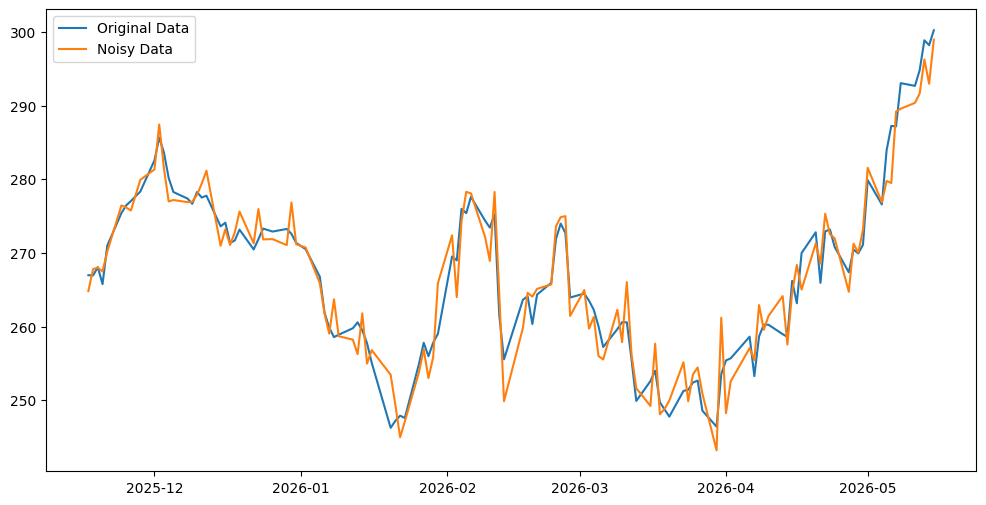

In [15]:
fig,ax=plt.subplots(figsize=(12,6))
ax.plot(prices.index,prices.iloc[:,0],label='Original Data')
ax.plot(prices.index,noisee1,label='Noisy Data')
plt.legend()

In [36]:



class KalmanFilter:

    def __init__(self,dt=1.0,q=1e-4):

        self.dt=dt #dt is one day
        self.device=torch.device("cuda" if torch.cuda.is_available() else "cpu")


        self.F=torch.tensor([
            [1.0, dt],
            [0.0, 1.0]
        ],device=self.device)


        self.H=torch.tensor([
            [1.0, 0.0]
        ],device=self.device)


        self.Q=torch.tensor([
            [1e-4, 0.0],
            [0.0,1e-4]
        ],device=self.device)


        self.R = torch.tensor([
            [1.0]
        ],device=self.device)


        self.x = torch.tensor([
            [current_price],
            [0.0]
        ],device=self.device)


        self.P = torch.eye(2, device=self.device)

        self.I = torch.eye(2, device=self.device)

    #prediction step
    def prediction(self):


        self.x =torch.matmul(self.F,self.x)
        self.P = torch.matmul(torch.matmul(self.F,self.P),self.F.T)+self.Q
     #updating as kalman filters are recurrsive
    def update(self, measurement):


        z = torch.tensor([
            [measurement]
        ], device=self.device)

        y = z-torch.matmul(self.H, self.x)

        S = torch.matmul(torch.matmul(self.H, self.P), self.H.T) + self.R

        K = torch.matmul(torch.matmul(self.P, self.H.T), torch.linalg.inv(S))




        self.x+=torch.matmul(K, y)

        self.P = (self.I - torch.matmul(K, self.H)).mm(self.P)

        return y.item()
     #wrapper function
    def predict(self):
        self.prediction()
    def filter(self, measurements):

        filtered_prices=[]
        filtered_velocities=[]
        innovations=[]

        for measurement in measurements:
            self.predict()

            innovation = self.update(measurement)

            filtered_prices.append(self.x[0, 0].item())
            filtered_velocities.append(self.x[1, 0].item())

            innovations.append(innovation)

        return (
            filtered_prices,
            filtered_velocities,
            innovations
        )

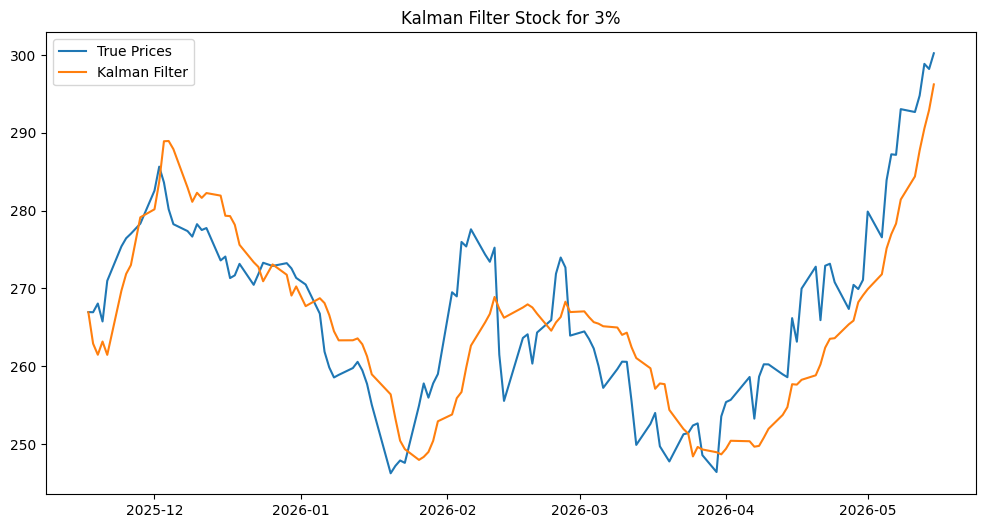

In [26]:
kf = KalmanFilter()

filtered_prices, velocities, innovations = kf.filter(noisee3)


plt.figure(figsize=(12,6))

plt.plot(dates,data["Close"], label="True Prices")
plt.plot(dates,filtered_prices, label="Kalman Filter")

plt.legend()
plt.title("Kalman Filter Stock for 3%")

plt.show()

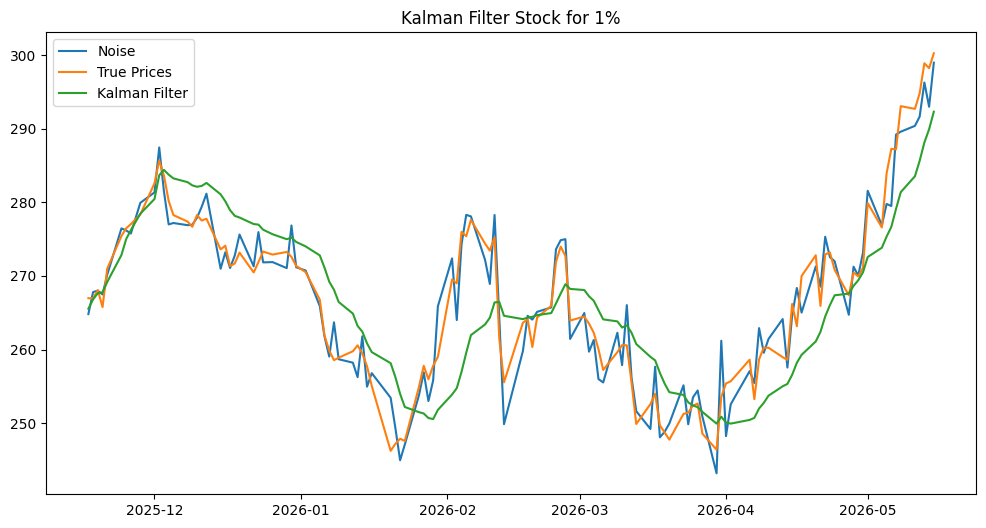

In [32]:
kf = KalmanFilter()

filtered_prices1, velocities, innovations = kf.filter(noisee1)


plt.figure(figsize=(12,6))
plt.plot(dates,noisee1, label="Noise")
plt.plot(dates,data["Close"], label="True Prices")
plt.plot(dates,filtered_prices1, label="Kalman Filter")

plt.legend()
plt.title("Kalman Filter Stock for 1%")

plt.show()

In [34]:
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr


true_prices = data["Close"].values.flatten()
corr, _ = pearsonr(true_prices, filtered_prices)
mse = mean_squared_error(true_prices, filtered_prices)
print(f"Mean_square_error for 1%: {mse}")

kf_noise2 = KalmanFilter()
filtered_prices_noise2, velocities_noise2, innovations_noise2 = kf_noise2.filter(noisee2)

corr_noise2, _ = pearsonr(true_prices, filtered_prices_noise2)
mse_noise2 = mean_squared_error(true_prices, filtered_prices_noise2)
print(f"Mean_square_error for 2%: {mse_noise2}")

kf_noise3 = KalmanFilter()
filtered_prices_noise3, velocities_noise3, innovations_noise3 = kf_noise3.filter(noisee3)

corr_noise3, _ = pearsonr(true_prices, filtered_prices_noise3)
mse_noise3 = mean_squared_error(true_prices, filtered_prices_noise3)
print(f"Mean_square_error for 3%: {mse_noise3}")

Mean_square_error for 1%: 46.616660729811095
Mean_square_error for 2%: 47.915735835832876
Mean_square_error for 3%: 46.616660729811095


In [35]:
print(f"correlation for 1 %: {corr}")
print(f"correlation for 2 %: {corr_noise2}")
print(f"correlation for 3 %: {corr_noise3}")


correlation for 1 %: 0.8348410451763499
correlation for 2 %: 0.8340221738493467
correlation for 3 %: 0.8348410451763499


Text(0.5, 1.0, 'Effect of Q Value on Mean Squared Error')

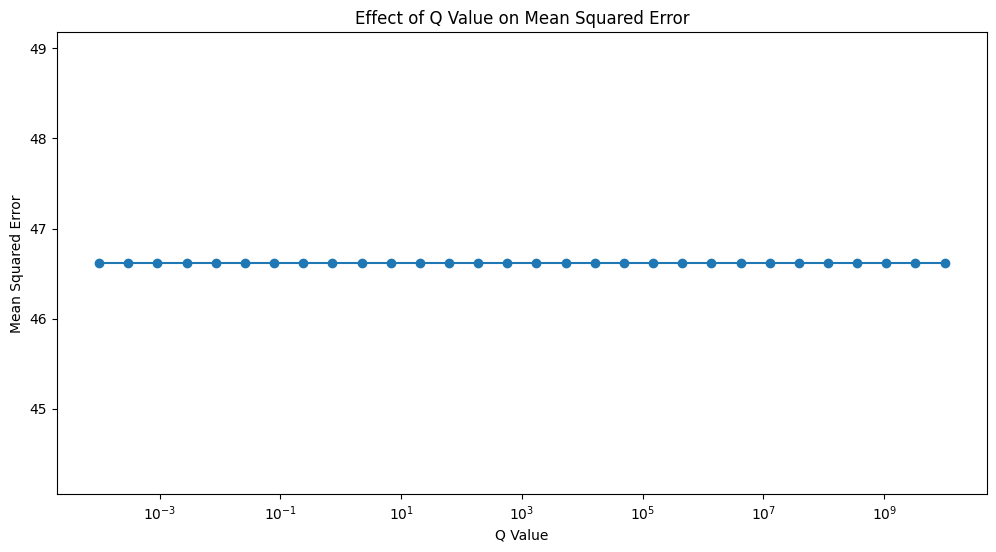

In [49]:
q_values=np.logspace(-4, -1, 30)
mse_values=[]
for q in q_values:
    kf = KalmanFilter(q=q)
    filtered_prices, velocities, innovations = kf.filter(noisee3)
    mse = mean_squared_error(true_prices, filtered_prices_noise3)
    mse_values.append(mse)

plt.figure(figsize=(12,6))
plt.plot(q_values, mse_values, marker='o')
plt.xscale('log')
plt.xlabel('Q Value')
plt.ylabel('Mean Squared Error')
plt.title('Effect of Q Value on Mean Squared Error')